In [1]:
import os,sys
import pandas as pd
import numpy as np
# import seaborn as sns
from matplotlib import ticker, cm
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
import matplotlib.patches as mpatches
%matplotlib inline
from tqdm import tqdm, trange
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.5
import SS_func

# Data Loading and visualization

In [2]:
# Getting the index of Ca atoms of the protein
# Replace the pdb file with you own
!awk '{if($3=="CA")printf "%d,",$2}END{printf "\n"}' /blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/ASNase_ASN_npt.pdb

5,26,38,52,71,85,104,123,133,147,154,161,175,194,204,211,218,225,237,248,258,272,294,305,319,340,354,364,371,393,409,416,432,447,461,480,496,510,520,538,550,567,586,608,620,639,649,663,679,701,708,723,740,756,772,786,805,812,823,840,852,869,883,895,907,923,947,966,980,999,1009,1031,1053,1072,1086,1100,1112,1122,1134,1156,1170,1182,1189,1209,1225,1244,1258,1275,1282,1296,1308,1322,1339,1354,1369,1383,1393,1414,1434,1453,1466,1485,1499,1515,1537,1547,1559,1583,1595,1611,1627,1644,1660,1667,1677,1694,1720,1732,1743,1757,1768,1785,1796,1806,1818,1827,1839,1859,1873,1892,1913,1927,1937,1953,1969,1983,1993,2003,2015,2037,2047,2058,2068,2082,2106,2113,2129,2148,2164,2180,2197,2211,2223,2237,2253,2272,2284,2291,2315,2327,2343,2357,2379,2393,2407,2421,2435,2447,2463,2473,2487,2507,2529,2540,2556,2570,2591,2600,2612,2631,2638,2659,2678,2695,2709,2716,2738,2757,2769,2790,2807,2831,2847,2859,2869,2893,2915,2932,2946,2957,2969,2985,2997,3017,3029,3045,3056,3078,3097,3111,3126,3147,3159,3181,3197,32

In [3]:
# Load COLVAR file into pandas for plotting
# Need to custmize the columns 
d1=pd.read_csv('/blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/FM/COLVAR',sep=' ')
d1.columns = ['delete1','time', 'd1', 'fps.lp', 'fps.ld', 'rmsd', 'funnel.bias','metad.bias', 'lwall.bias', 'lwall.force2','uwall-rmsd.bias', 'uwall-rmsd.force2','uwall.bias', 'uwall.force2','distwall.bias' ,'distwall.force2','delete2']
d1 = d1.drop(columns=['delete1', 'delete2'])
d1['Time'] = d1['time']/1000

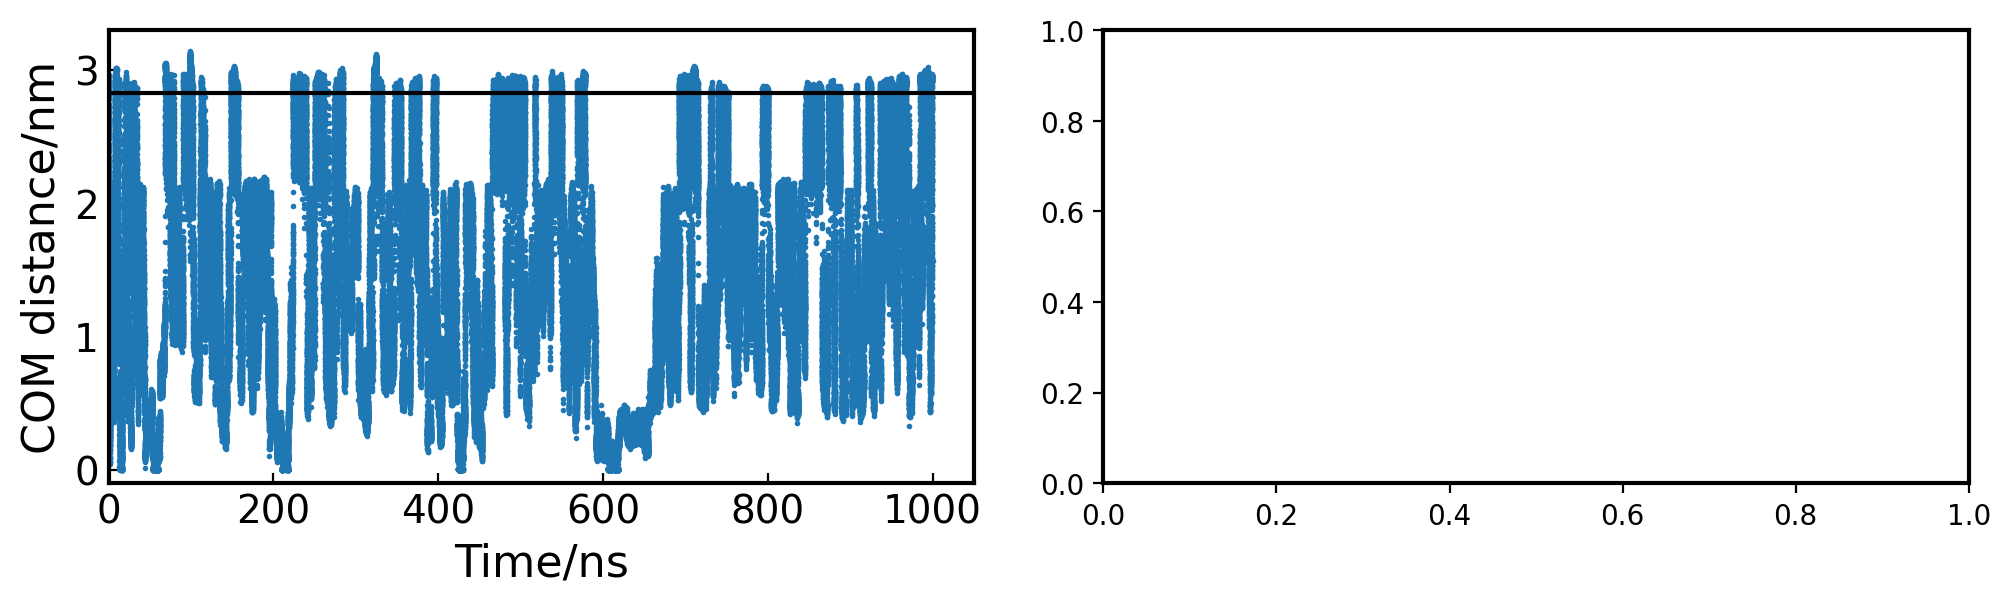

In [8]:
# Plot to check 'diffusion' behavior
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,3),dpi=200)
fig.subplots_adjust(hspace =0.2, wspace=0.15)
ax1.plot(d1["Time"][::5],d1["d1"][::5],'o', ms=1,label='d0')
ax1.set_xlim(0,)
ax1.set_ylim(-0.1,)
ax1.set_ylabel("COM distance/nm",fontsize=16)
ax1.set_xlabel("Time/ns",fontsize=16)
ax1.xaxis.set_tick_params(labelsize=14)
ax1.yaxis.set_tick_params(labelsize=14)
ax1.tick_params(direction="in")
ax1.axhline(y=2.83,c='black')

# ax2.plot(d1_2["Time"][::5],d1_2["d1"][::5],'o', ms=1,label='d0')
# ax2.set_xlim(0,)
# ax2.set_ylim(-0.1,)
# ax2.set_ylabel("COM distance/nm",fontsize=16)
# ax2.set_xlabel("Time/ns",fontsize=16)
# ax2.xaxis.set_tick_params(labelsize=14)
# ax2.yaxis.set_tick_params(labelsize=14)
# ax2.tick_params(direction="in")


In [11]:
# Load processed FES data
ASNase_ASN_FM_MW_t2 = {}  # Dictionary to store the DataFrames

for i in range(0, 2001,1):
    file_name = f"/blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/FM_7_MW/FES/fes_{i}.dat"  # file names 
    with open(file_name, 'r') as f:
        lines = [next(f) for _ in range(10)]
    
    # Extract column names from the first line
    col_names = lines[0].split()[2:]  # The column names start from the third word
    
    try:
        # Skip the first 9 lines (0-based index) when reading the file
        df_t = pd.read_csv(file_name, skiprows=5, delim_whitespace=True, names=col_names)
        ASNase_ASN_FM_MW_t2[i] = df_t  # Store the DataFrame in the dictionary with the number as the key
    except FileNotFoundError:
        print(f"File '{file_name}' not found.")
 

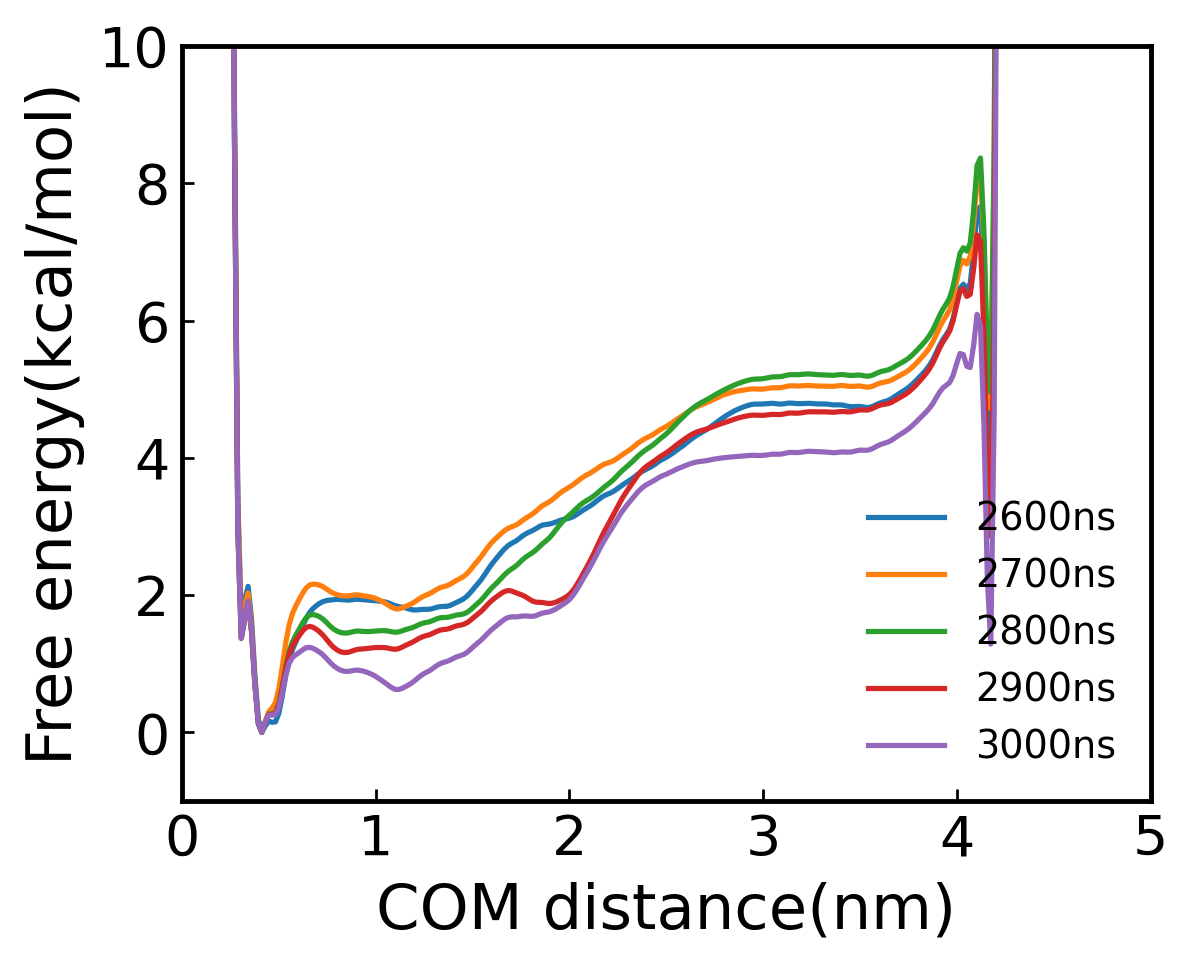

In [12]:
# Plot the FES every other x ns to check convergence
fig, axs = plt.subplots(1, 1, figsize=(5,4),dpi=250)  # generate canvas
for i in range (1300,1501,50):
    axs.plot(ASNase_ASN_FM_MW_t2[i].iloc[:,0],0.239006*ASNase_ASN_FM_MW_t2[i].iloc[:,1], label=str(int((i)*2))+"ns")

plt.legend(ncol=1,loc='lower right',frameon=False,fontsize=11)  
axs.set_xlim(0,5)
axs.tick_params(direction="in")
plt.xlabel("COM distance(nm)", fontsize=18)
plt.ylabel("Free energy(kcal/mol)", fontsize=18)
axs.xaxis.set_tick_params(labelsize=16)
axs.yaxis.set_tick_params(labelsize=16)
plt.ylim(-1,10)
# axs.axvline(x=0.27,c='red')
for axis in ['top', 'bottom', 'left', 'right']:
    axs.spines[axis].set_linewidth(1.4)

# Convergence

Follow the logic of the ffs_tk to assess the convergence using python

In [9]:
#!/usr/bin/env python3
import numpy as np
import sys
import glob
import re
import os

# --- Constants ---
# Converts nm^3 to L and incorporates Avogadro's number for 1 M standard concentration
C0_CONVERSION = 0.6022
# Conversion factor from kJ to kcal
KJ_TO_KCAL = 1 / 4.184

def _get_filenumber(filepath):
    """Safely extracts the numerical part of a filename like 'fes_100.dat'."""
    match = re.search(r'(\d+)', os.path.basename(filepath))
    if match:
        return int(match.group(1))
    return -1 # Return a value that indicates failure

def calculate_binding_free_energy(filepath, kt, rcyl, bound_min, bound_max, unbound_cv1, verbose=False):
    """
    Calculates absolute binding free energy from a single Funnel Metadynamics FES file.

    Args:
        filepath (str): Path to the FES file from plumed sum_hills.
        kt (float): Thermal energy (kT) of the simulation in kJ/mol (e.g., 2.494 for 300K).
        rcyl (float): Radius of the funnel cylinder (R_cyl) in nm.
        bound_min (list): Minimum CV values for the bound state region (e.g., [0.5, -1.0]).
        bound_max (list): Maximum CV values for the bound state region (e.g., [1.5, 1.0]).
        unbound_cv1 (float): A CV1 value that defines the unbound/reference plateau region.
        verbose (bool): If True, prints detailed steps and results to the console.

    Returns:
        dict: A dictionary with the final free energy, e.g., {'kj_mol': -45.5, 'kcal_mol': -10.9}, or None on failure.
    """
    if verbose:
        print(f"--- Analyzing '{os.path.basename(filepath)}' ---")

    # Step 1: Load FES data and parse header
    try:
        header_lines = []
        with open(filepath, 'r') as f:
            for line in f:
                if line.strip().startswith('#!'):
                    header_lines.append(line)
                else:
                    break
        fes_data = np.loadtxt(filepath)

        # Robustly parse header to find dimensions and energy column
        fields_line = [line for line in header_lines if 'FIELDS' in line]
        if not fields_line: raise ValueError("'#! FIELDS' line not found in header.")
        
        fields = fields_line[0].split()
        try:
            # Find the free energy column (e.g., 'file.free')
            energy_col_name = [f for f in fields if '.free' in f][0]
            energy_col_idx = fields.index(energy_col_name) - 2 # Account for '#!' and 'FIELDS'
        except IndexError:
            raise ValueError("Could not find a '.free' column in '#! FIELDS' line.")
            
        cv_names = [f for f in fields[2:] if not f.startswith('der_') and '.free' not in f]
        num_dims = len(cv_names)
        
        # --- CORRECTED METADATA PARSING BLOCK ---
        metadata = {'min': [], 'max': [], 'nbins': []}
        for line in header_lines:
            parts = line.split()
            # Check for the '#! SET ...' format
            if len(parts) >= 4 and parts[1] == 'SET':
                key = parts[2]
                value_str = parts[3]
                if key.startswith('min_'):
                    metadata['min'].append(float(value_str.replace('-pi', f'{-np.pi}').replace('pi', f'{np.pi}')))
                elif key.startswith('max_'):
                    metadata['max'].append(float(value_str.replace('-pi', f'{-np.pi}').replace('pi', f'{np.pi}')))
                elif key.startswith('nbins_'):
                    metadata['nbins'].append(int(value_str))
        if len(bound_min) != num_dims or len(bound_max) != num_dims:
             raise ValueError(f"Number of bounds ({len(bound_min)}) does not match FES dimensionality ({num_dims}).")

    except (FileNotFoundError, ValueError) as e:
        print(f"Warning: Could not process file '{filepath}'. Reason: {e}")
        return None

    # Step 2: Calculate grid spacing (dr)
    dr = [(metadata['max'][i] - metadata['min'][i]) / metadata['nbins'][i] for i in range(num_dims)]
    integration_element = np.prod(dr)

    # Step 3: Determine reference energy (W_ref)
    unbound_slice = fes_data[(fes_data[:, 0] >= unbound_cv1) & (fes_data[:, 0] <= unbound_cv1 + dr[0])] # get the W_ref at the specified unbounded state
    if len(unbound_slice) == 0:
        print(f"Warning: No data in unbound region for '{os.path.basename(filepath)}'. Skipping.")
        return None
    w_ref = np.mean(unbound_slice[:, energy_col_idx])

    # Step 4: Integrate over the bound state
    bound_mask = np.full(fes_data.shape[0], True)
    for i in range(num_dims):
        bound_mask &= (fes_data[:, i] >= bound_min[i]) & (fes_data[:, i] <= bound_max[i])
    
    bound_energies = fes_data[bound_mask][:, energy_col_idx]
    if len(bound_energies) == 0:
        print(f"Warning: No data in bound region for '{os.path.basename(filepath)}'. Skipping.")
        return None

    finite_energies = bound_energies[np.isfinite(bound_energies)]
    boltzmann_factors = np.exp(-(finite_energies - w_ref) / kt)
    integral_kb = np.sum(boltzmann_factors) * integration_element

    if integral_kb <= 0:
        print(f"Warning: Non-positive integral for '{os.path.basename(filepath)}'. Skipping.")
        return None

    # Step 5: Calculate final absolute binding free energy
    log_argument = integral_kb * np.pi * rcyl**2 * C0_CONVERSION
    delta_g_b0_kj = -kt * np.log(log_argument)
    delta_g_b0_kcal = delta_g_b0_kj * KJ_TO_KCAL
        
    return {'kj_mol': delta_g_b0_kj, 'kcal_mol': delta_g_b0_kcal}

def analyze_convergence(directory, file_pattern, kt, rcyl, bound_min, bound_max, unbound_cv1, output_file='convergence_dg.dat', reject_time=0, num_files=None):
    """
    Analyzes a series of FES files (fes_*.dat) to assess convergence of the binding free energy.

    Args:
        directory (str): The directory containing the FES files.
        file_pattern (str): A pattern to match the files (e.g., 'fes_*.dat').
        kt, rcyl, bound_min, bound_max, unbound_cv1: Same parameters as the single-file function.
        output_file (str): Name of the file to save convergence data.
        reject_time (int): The number of initial FES files to exclude from averaging.
        num_files (int, optional): The maximum number of FES files to process. Defaults to None (process all).
    """    
    print(f"--- Starting Convergence Analysis in Directory '{directory}' ---")
    
    # Find and sort FES files numerically
    search_path = os.path.join(directory, file_pattern)
    files = glob.glob(search_path)
    if not files:
        print(f"Error: No files found matching pattern '{search_path}'.")
        return

    files.sort(key=_get_filenumber)
    
    # Process only a subset of files if specified
    if num_files is not None and num_files > 0:
        print(f"Processing the first {num_files} of {len(files)} found files.")
        files = files[:num_files]    

    print(f"Found {len(files)} FES files to analyze.")

    results = []
    for f in files:
        time_step = _get_filenumber(f)
        if time_step == -1:
            print(f"Warning: Could not extract time step number from '{f}'. Skipping.")
            continue
        
        dg_result = calculate_binding_free_energy(f, kt, rcyl, bound_min, bound_max, unbound_cv1, verbose=False)
        if dg_result:
            results.append((time_step, dg_result['kj_mol'])) # get from 
        else:
            print(f"--> File '{os.path.basename(f)}' could not be processed successfully.")

    if len(results) < 2:
        print("\nERROR: Could not get enough valid results to perform convergence analysis.")
        print("Please check the warnings above and verify your input parameters.")
        return
        
    # Write detailed output file
    with open(output_file, 'w') as f:
        f.write("TimeStep     dG(kJ/mol)    Mean_OTF(kJ/mol)   TW_Mean_OTF(kJ/mol)  SEM_OTF(kJ/mol)    STD_error_OTF(kJ/mol)\n")
        
        dg_values = np.array([res[1] for res in results])
        times = np.array([res[0] for res in results])
        
        valid_indices = np.where(times > reject_time)[0]
        if len(valid_indices) > 0:
            dg_for_avg = dg_values[valid_indices]
            times_for_avg = times[valid_indices]

            # Method 1: Standard (unweighted) Mean and SEM
            expanding_mean = np.array([np.mean(dg_for_avg[:i+1]) for i in range(len(dg_for_avg))])
            expanding_sem = np.array([np.std(dg_for_avg[:i+1], ddof=1)/np.sqrt(i+1) if i > 0 else 0 for i in range(len(dg_for_avg))])
            
            # Method 2: Time-Weighted Mean (from TCL script)
            expanding_tw_mean = []
            expanding_weighted_std = []
            for i in range(len(dg_for_avg)):
                current_dGs = dg_for_avg[:i+1]
                current_times = times_for_avg[:i+1]
                weights = current_times - reject_time
                if np.sum(weights) > 0:
                    # Calculate weighted mean
                    weighted_mean = np.average(current_dGs, weights=weights)
                    expanding_tw_mean.append(weighted_mean)
                    # Calculate weighted standard deviation
                    weighted_variance = np.average((current_dGs - weighted_mean)**2, weights=weights)
                    expanding_weighted_std.append(np.sqrt(weighted_variance))
                else:
                    expanding_tw_mean.append(np.mean(current_dGs)) # Fallback for first point
                    expanding_weighted_std.append(0)
            
            # Print to file
            idx_counter = 0
            for i, (time, dg) in enumerate(results):
                if time > reject_time and idx_counter < len(expanding_mean):
                    f.write(f"{time:<12} {dg:<15.4f} {expanding_mean[idx_counter]:<20.4f} {expanding_tw_mean[idx_counter]:<20.4f} {expanding_sem[idx_counter]:<20.4f} {expanding_weighted_std[idx_counter]:<20.4f}\n")
                    idx_counter += 1
                else:
                    f.write(f"{time:<12} {dg:<15.4f} {'N/A':<20} {'N/A':<20} {'N/A':<20} {'N/A':<20}\n")
            
            final_mean_kj = expanding_mean[-1]
            final_tw_mean_kj = expanding_tw_mean[-1]
            final_sem_kj = expanding_sem[-1]
            final_weighted_std_kj = expanding_weighted_std[-1]
            
            final_mean_kcal = final_mean_kj * KJ_TO_KCAL
            final_sem_kcal = final_sem_kj * KJ_TO_KCAL
            final_tw_mean_kcal = final_tw_mean_kj * KJ_TO_KCAL
            final_weighted_std_kcal = final_weighted_std_kj * KJ_TO_KCAL

            print("\n" + "="*80)
            print("                CONVERGENCE ANALYSIS SUMMARY")
            print("="*80)
            print(f"Data saved to '{output_file}'.")
            print(f"Analysis based on {len(dg_for_avg)} data points (after rejecting first {reject_time} steps).")
            print(f"\nFinal Unweighted ΔG°_b (Mean ± SEM): {final_mean_kj:.2f} ± {final_sem_kj:.2f} kJ/mol")
            print(f"Final Unweighted ΔG°_b (Mean ± SEM): {final_mean_kcal:.2f} ± {final_sem_kcal:.2f} kcal/mol")
            print(f"\nFinal Time-Weighted ΔG°_b (Mean ± STD) (TCL method): {final_tw_mean_kj:.2f} ± {final_weighted_std_kj:.2f} kJ/mol")
            print(f"Final Time-Weighted ΔG°_b (Mean ± STD) (TCL method): {final_tw_mean_kcal:.2f} ± {final_weighted_std_kcal:.2f} kcal/mol")
            print("="*80)
        else:
             print("No data points left after applying rejection criteria. Cannot perform averaging.")


In [10]:
## Usage 
if __name__ == '__main__':
    print("--- Example of 1D Convergence Analysis ---\n")
    
    # 1. --- Define parameters for the 1D analysis ---
    FES_DIRECTORY = '/blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/FM_7_MW/FES/'
    FES_PATTERN = 'fes_*.dat'
    OUTPUT_FILE = 'ASNase_Final_Convergence.dat'
    KT_IN_KJ_MOL = 2.576
    FUNNEL_RADIUS_NM = 0.1
    BOUND_CV_MIN = [0]       # Note: List with one value for 1D
    BOUND_CV_MAX = [2.1]       # Note: List with one value for 1D
    UNBOUND_CV1_REGION = 3
    REJECT_INITIAL_STEPS = 1300
    NUMBER_OF_FILES_TO_PROCESS = 1500

    # 2. --- Create dummy 1D fes_*.dat files for demonstration ---
    print(f"INFO: Checking for dummy files matching '{FES_PATTERN}'...")
    if not glob.glob(os.path.join(FES_DIRECTORY, FES_PATTERN)):
        print("INFO: No dummy files found. Creating a 1D set for demonstration.")
        header = "#! FIELDS d1 file.free der_d1\n#! SET min_d1 0.0\n#! SET max_d1 5.0\n#! SET nbins_d1 100\n#! SET periodic_d1 false"
        for i in range(20):
            filepath = os.path.join(FES_DIRECTORY, f'fes_{i}.dat')
            cv1 = np.linspace(0.0, 5.0, 100)
            # Simulate convergence with noise
            well_depth = -35 - (i / 2) + np.random.rand()
            energy = 5 + well_depth * np.exp(-((cv1 - 0.5)**2 / 0.1))
            energy[cv1 > 3.5] = 0.0 # Flat unbound plateau
            deriv = np.gradient(energy, cv1)
            dummy_data = np.vstack([cv1, energy, deriv]).T
            np.savetxt(filepath, dummy_data, header=header, comments='', fmt='%.6f')
    else:
        print("INFO: Existing files found. Using them for the example.")
        
    # 3. --- Call the convergence analysis function ---
    analyze_convergence(
        directory=FES_DIRECTORY,
        file_pattern=FES_PATTERN,
        kt=KT_IN_KJ_MOL,
        rcyl=FUNNEL_RADIUS_NM,
        bound_min=BOUND_CV_MIN,
        bound_max=BOUND_CV_MAX,
        unbound_cv1=UNBOUND_CV1_REGION,
        reject_time=REJECT_INITIAL_STEPS,
        output_file=OUTPUT_FILE,
        num_files=NUMBER_OF_FILES_TO_PROCESS
    )

--- Example of 1D Convergence Analysis ---

INFO: Checking for dummy files matching 'fes_*.dat'...
INFO: Existing files found. Using them for the example.
--- Starting Convergence Analysis in Directory '/blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/FM_7_MW/FES/' ---
Processing the first 1500 of 2001 found files.
Found 1500 FES files to analyze.

                CONVERGENCE ANALYSIS SUMMARY
Data saved to 'ASNase_Final_Convergence.dat'.
Analysis based on 199 data points (after rejecting first 1300 steps).

Final Unweighted ΔG°_b (Mean ± SEM): -5.93 ± 0.06 kJ/mol
Final Unweighted ΔG°_b (Mean ± SEM): -1.42 ± 0.01 kcal/mol

Final Time-Weighted ΔG°_b (Mean ± STD) (TCL method): -5.63 ± 1.00 kJ/mol
Final Time-Weighted ΔG°_b (Mean ± STD) (TCL method): -1.35 ± 0.24 kcal/mol


# Final plot

In [13]:
# From python
ASNase_ASN_MW_cov_T2=pd.read_csv('./ASNase_MW_T2_Convergence.dat', delim_whitespace=True, na_values='N/A',engine='python')

(-30.0, 5.0)

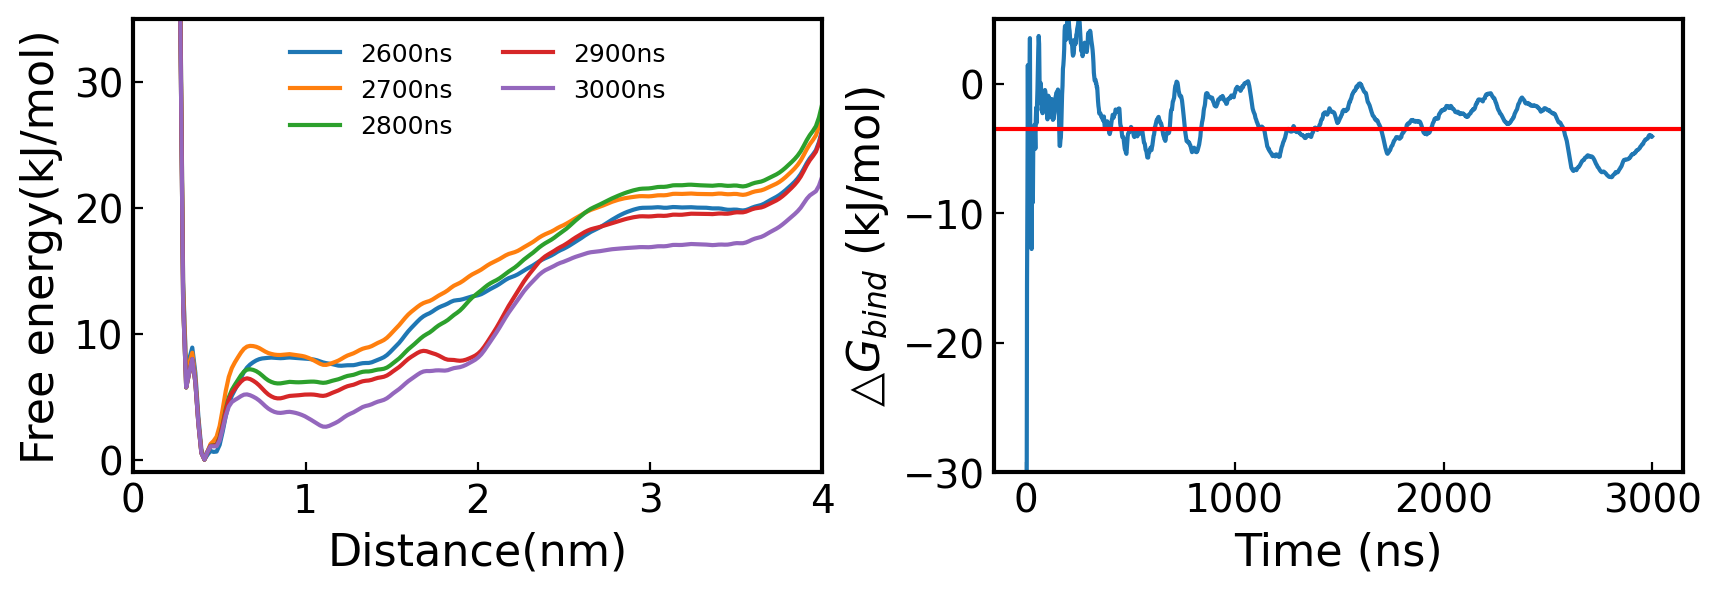

In [14]:
fig,axs=plt.subplots(1,2,figsize=(10,3),dpi=200,sharex = False, sharey =  False)
fig.subplots_adjust(hspace =0, wspace=0.25)
for i in range (1300,1501,50):
    axs[0].plot(ASNase_ASN_FM_MW_t2[i].iloc[:,0],ASNase_ASN_FM_MW_t2[i].iloc[:,1], label=str(int((i)*2))+"ns")
axs[0].set_xlabel("Distance(nm)", fontsize=16)
axs[0].set_ylabel("Free energy(kJ/mol)", fontsize=16)
axs[0].xaxis.set_tick_params(labelsize=14)
axs[0].yaxis.set_tick_params(labelsize=14)
axs[0].set_xlim(0,4)
axs[0].set_ylim(-1,35)
axs[0].tick_params(direction="in")
axs[0].legend(ncol=2,loc='upper center',frameon=False,fontsize=9)  

axs[1].plot(ASNase_ASN_MW_cov_T2.iloc[:,0][::1]*2,ASNase_ASN_MW_cov_T2.iloc[:,1][::1])
axs[1].xaxis.set_tick_params(labelsize=14)
axs[1].yaxis.set_tick_params(labelsize=14)
axs[1].set_xlabel("Time (ns)", fontsize=16)
axs[1].set_ylabel(r"$△G_{bind}$ (kJ/mol)", fontsize=16)
axs[1].tick_params(direction="in")
axs[1].axhline(y=-3.50,c='red')
axs[1].set_ylim(-30,5)


# Recover 2D FES

**Use PLUMED to perfrom reweighting** \
plumed driver --mf_xtc traj.xtc --plumed plumed_reweight.dat --kt 2.494339 \
**Example plumed_rewight.dat file in the FM folder** \
**READ more from PLUMED document**

In [15]:
# Load the processed Data
file_name = f"/blue/jsampath/jiayinhao/RHPs/ASNase/ASNase/with_ASN/Align_1/FM_7_MW/reweighting/ffphi.dat"  # file names 
with open(file_name, 'r') as f:
    lines = [next(f) for _ in range(10)]

# Extract column names from the first linebb
col_names = lines[0].split()[2:]  # The column names start from the third word

try:
    # Skip the first 9 lines (0-based index) when reading the file
    df_t = pd.read_csv(file_name, skiprows=10, delim_whitespace=True, names=col_names)
except FileNotFoundError:
    print(f"File '{file_name}' not found.")


In [16]:
# Turn the data into right shape
fps_lp  = np.array(df_t["fps.lp"]).reshape(201, 501) # (bin# of theta1, bin# of d0)## (opposite)
fps_ld  = np.array(df_t["fps.ld"]).reshape(201, 501)
fes_mtd1 = np.array(df_t["fps_ff"]).reshape(201, 501)

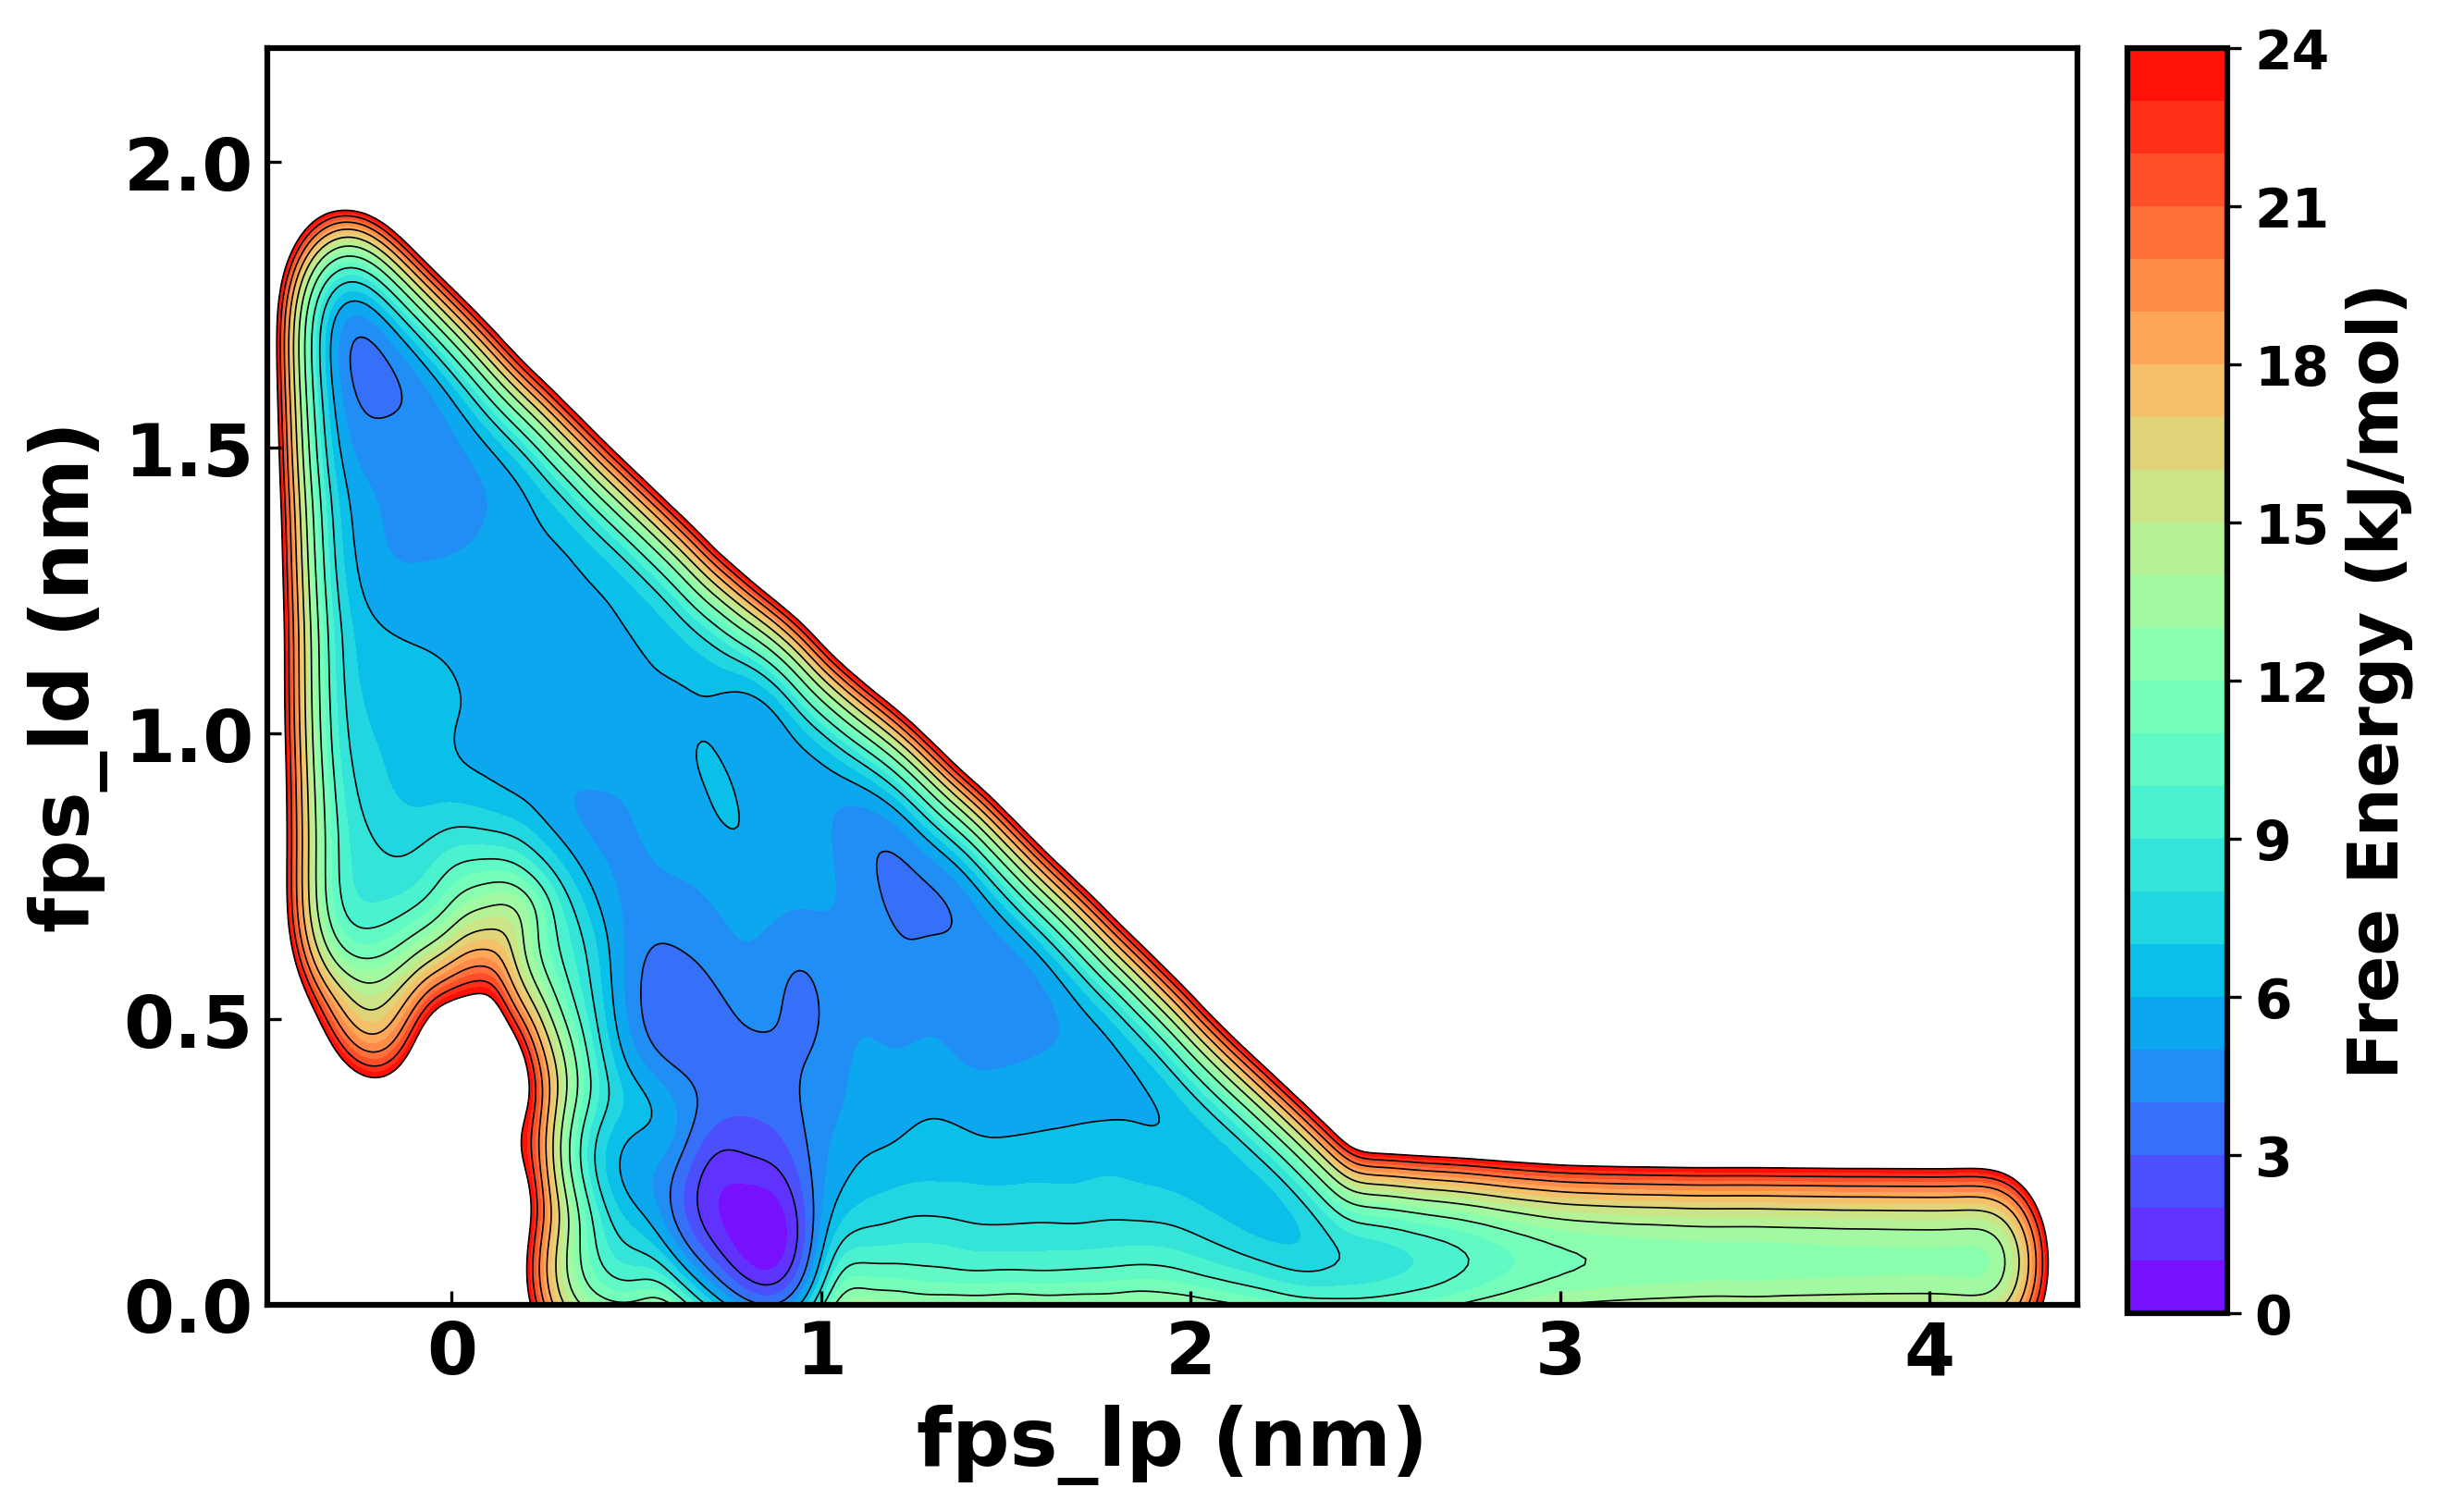

In [17]:
# Plot 2D FES with fps_ld and fps_lp
fig, axs=plt.subplots(1,1, figsize=(9,6),dpi=300)
cntr = axs.contourf(fps_lp,fps_ld,fes_mtd1, levels=range(0,25), cmap=cm.rainbow)
axs.contour(fps_lp,fps_ld,fes_mtd1, levels=range(0,25,2), linewidths=0.4, colors='k')
axs.set_xlabel('fps_lp (nm)',fontsize=21,weight='bold')
axs.set_ylabel('fps_ld (nm)',fontsize=21,weight='bold')
axs.set_xlim(-0.5,4.4)
axs.set_ylim(0,2.2)
axs.xaxis.set_tick_params(labelsize=19)
axs.yaxis.set_tick_params(labelsize=19)
axs.tick_params(axis='both', which='both',direction="in")
for tick in axs.xaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')
for tick in axs.yaxis.get_major_ticks():
    tick.label1.set_fontweight('bold')

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.12, 0.04, 0.76])
cbar = plt.colorbar(cntr,cax=cbar_ax)
# Change the color bar tick font size
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('bold')
cbar.set_label('Free Energy (kJ/mol)',fontsize=18,weight='bold')
